In [1]:
import os
from PIL import Image
import pandas as pd

In [3]:
img_dir = "Uploads/1"

records = []

for fname in os.listdir(img_dir):
    if fname.lower().endswith((".png", ".jpg", ".jpeg")):
        path = os.path.join(img_dir, fname)
        with Image.open(path) as img:
            w, h = img.size
            records.append({
                "file": fname,
                "width": w,
                "height": h,
                "aspect_ratio": round(w / h, 3)
            })

df = pd.DataFrame(records)

print(df.head())
print("\nSummary:")
print(df.describe())

print("\nUnique dimensions:")
print(df[["width", "height"]].drop_duplicates())

       file  width  height  aspect_ratio
0    h1.png   1920    1080         1.778
1   h10.png   1920    1080         1.778
2  h100.png   1920    1080         1.778
3   h11.png   1920    1080         1.778
4   h12.png   1920    1080         1.778

Summary:
        width  height  aspect_ratio
count   100.0   100.0  1.000000e+02
mean   1920.0  1080.0  1.778000e+00
std       0.0     0.0  6.694897e-16
min    1920.0  1080.0  1.778000e+00
25%    1920.0  1080.0  1.778000e+00
50%    1920.0  1080.0  1.778000e+00
75%    1920.0  1080.0  1.778000e+00
max    1920.0  1080.0  1.778000e+00

Unique dimensions:
   width  height
0   1920    1080


In [4]:
import os
import json
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [6]:
BASE_DIR = Path("/mnt/f/CocDatasets/Perception1")
UPLOADS_DIR = BASE_DIR / "Uploads" / "1"
ANNOTATION_FILE = BASE_DIR / "CvatExport" / "coco_annotation_1" / "annotations" / "instances_Train.json"

print("Uploads exists:", UPLOADS_DIR.exists())
print("Annotation exists:", ANNOTATION_FILE.exists())

Uploads exists: True
Annotation exists: True


In [7]:
image_files = sorted([
    f for f in UPLOADS_DIR.iterdir()
    if f.suffix.lower() in [".png", ".jpg", ".jpeg"]
])

print(f"Total images found: {len(image_files)}")
image_files[:5]

Total images found: 100


[PosixPath('/mnt/f/CocDatasets/Perception1/Uploads/1/h1.png'),
 PosixPath('/mnt/f/CocDatasets/Perception1/Uploads/1/h10.png'),
 PosixPath('/mnt/f/CocDatasets/Perception1/Uploads/1/h100.png'),
 PosixPath('/mnt/f/CocDatasets/Perception1/Uploads/1/h11.png'),
 PosixPath('/mnt/f/CocDatasets/Perception1/Uploads/1/h12.png')]

In [8]:
records = []

for img_path in image_files:
    with Image.open(img_path) as img:
        w, h = img.size
        records.append({
            "file": img_path.name,
            "width": w,
            "height": h,
            "aspect_ratio": round(w / h, 3)
        })

img_df = pd.DataFrame(records)

img_df.head()

,file,width,height,aspect_ratio
0,h1.png,1920,1080,1.778
1,h10.png,1920,1080,1.778
2,h100.png,1920,1080,1.778
3,h11.png,1920,1080,1.778
4,h12.png,1920,1080,1.778


In [9]:
img_df.describe()

,width,height,aspect_ratio
count,100.0,100.0,1.000000e+02
mean,1920.0,1080.0,1.778000e+00
std,0.0,0.0,6.694897e-16
min,1920.0,1080.0,1.778000e+00
25%,1920.0,1080.0,1.778000e+00
50%,1920.0,1080.0,1.778000e+00
75%,1920.0,1080.0,1.778000e+00
max,1920.0,1080.0,1.778000e+00


In [10]:
with open(ANNOTATION_FILE, "r") as f:
    coco = json.load(f)

print("Keys:", coco.keys())
print("Images:", len(coco["images"]))
print("Annotations:", len(coco["annotations"]))
print("Categories:", len(coco["categories"]))

Keys: dict_keys(['licenses', 'info', 'categories', 'images', 'annotations'])
Images: 100
Annotations: 2976
Categories: 15


In [11]:
cat_map = {c["id"]: c["name"] for c in coco["categories"]}
cat_map

{1: 'canon',
 2: 'archer_tower',
 3: 'mortar',
 4: 'air_defense',
 5: 'wizard_tower',
 6: 'air_sweeper',
 7: 'bomb_tower',
 8: 'x_bow',
 9: 'inferno_tower',
 10: 'eagle_artillery',
 11: 'town_hall',
 12: 'gold_storage',
 13: 'elixer_storage',
 14: 'dark_elixer_storage',
 15: 'clan_castle'}

In [12]:
ann_rows = []

for ann in coco["annotations"]:
    bbox = ann["bbox"]
    seg = ann.get("segmentation", [])

    ann_rows.append({
        "ann_id": ann["id"],
        "image_id": ann["image_id"],
        "category_id": ann["category_id"],
        "class_name": cat_map[ann["category_id"]],
        "bbox_x": bbox[0],
        "bbox_y": bbox[1],
        "bbox_w": bbox[2],
        "bbox_h": bbox[3],
        "area": ann["area"],
        "polygon_points": len(seg[0]) // 2 if seg else 0
    })

ann_df = pd.DataFrame(ann_rows)

ann_df.head()

,ann_id,image_id,category_id,class_name,bbox_x,bbox_y,bbox_w,bbox_h,area,polygon_points
0,1,1,13,elixer_storage,679.39,679.65,91.22,88.10,4808.0,14
1,2,1,2,archer_tower,884.35,573.25,65.87,85.58,3792.0,7
2,3,1,1,canon,670.31,199.31,82.84,70.15,2990.0,14
3,4,1,1,canon,859.57,954.04,73.11,67.87,2843.0,7
4,5,1,1,canon,540.14,710.70,82.47,65.24,2655.0,17


class_name
archer_tower           453
canon                  362
wizard_tower           295
gold_storage           270
x_bow                  263
elixer_storage         255
mortar                 214
air_defense            188
inferno_tower          176
air_sweeper            124
bomb_tower             121
eagle_artillery         65
town_hall               64
dark_elixer_storage     64
clan_castle             62
Name: count, dtype: int64


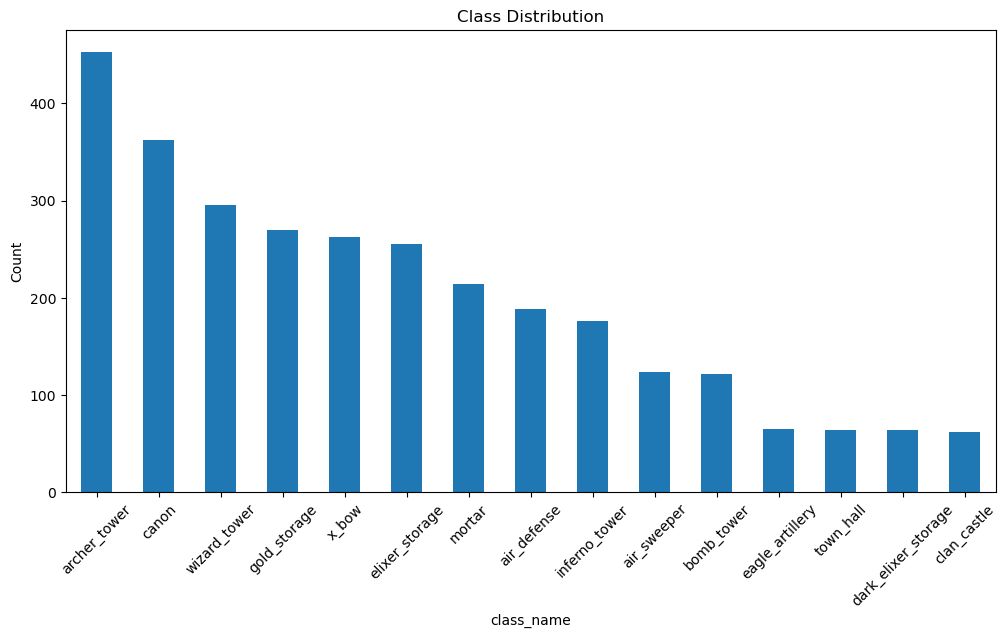

In [13]:
class_counts = ann_df["class_name"].value_counts()

print(class_counts)

plt.figure(figsize=(12,6))
class_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

count    98.000000
mean     30.367347
std      13.988499
min       5.000000
25%      19.000000
50%      29.500000
75%      42.000000
max      51.000000
dtype: float64


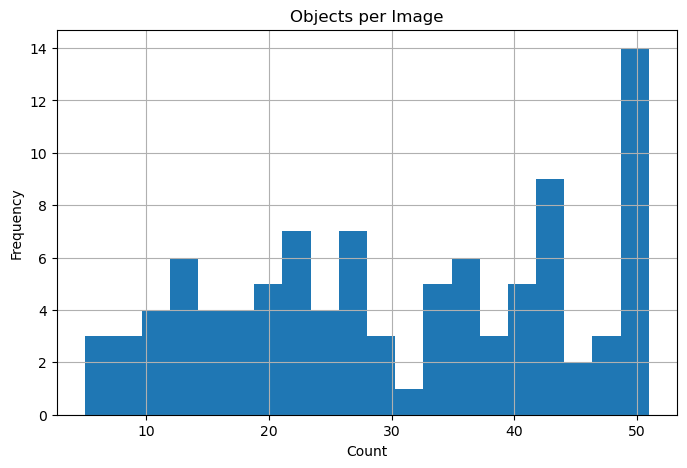

In [14]:
objects_per_image = ann_df.groupby("image_id").size()

print(objects_per_image.describe())

plt.figure(figsize=(8,5))
objects_per_image.hist(bins=20)
plt.title("Objects per Image")
plt.xlabel("Count")
plt.ylabel("Frequency")
plt.show()

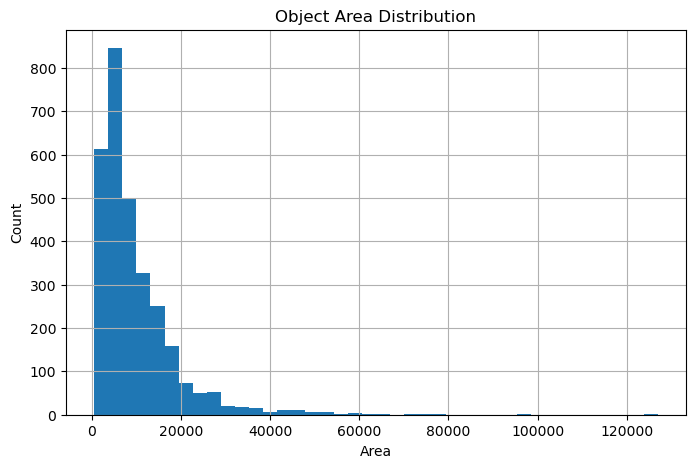

In [15]:
plt.figure(figsize=(8,5))
ann_df["area"].hist(bins=40)
plt.title("Object Area Distribution")
plt.xlabel("Area")
plt.ylabel("Count")
plt.show()

count    2976.000000
mean       11.429099
std         3.784579
min         3.000000
25%         9.000000
50%        11.000000
75%        14.000000
max        37.000000
Name: polygon_points, dtype: float64


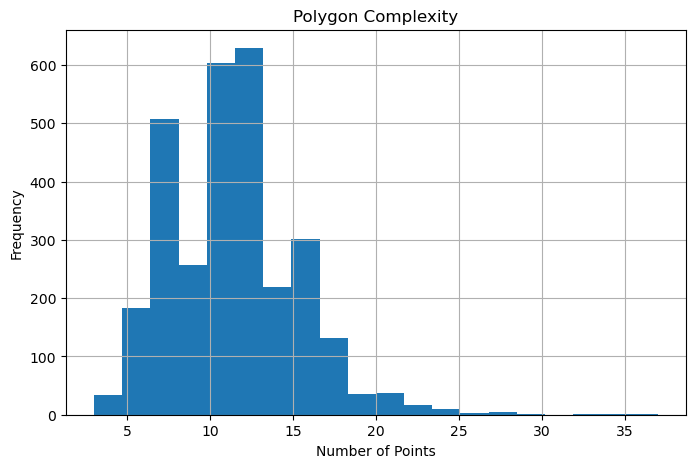

In [16]:
print(ann_df["polygon_points"].describe())

plt.figure(figsize=(8,5))
ann_df["polygon_points"].hist(bins=20)
plt.title("Polygon Complexity")
plt.xlabel("Number of Points")
plt.ylabel("Frequency")
plt.show()

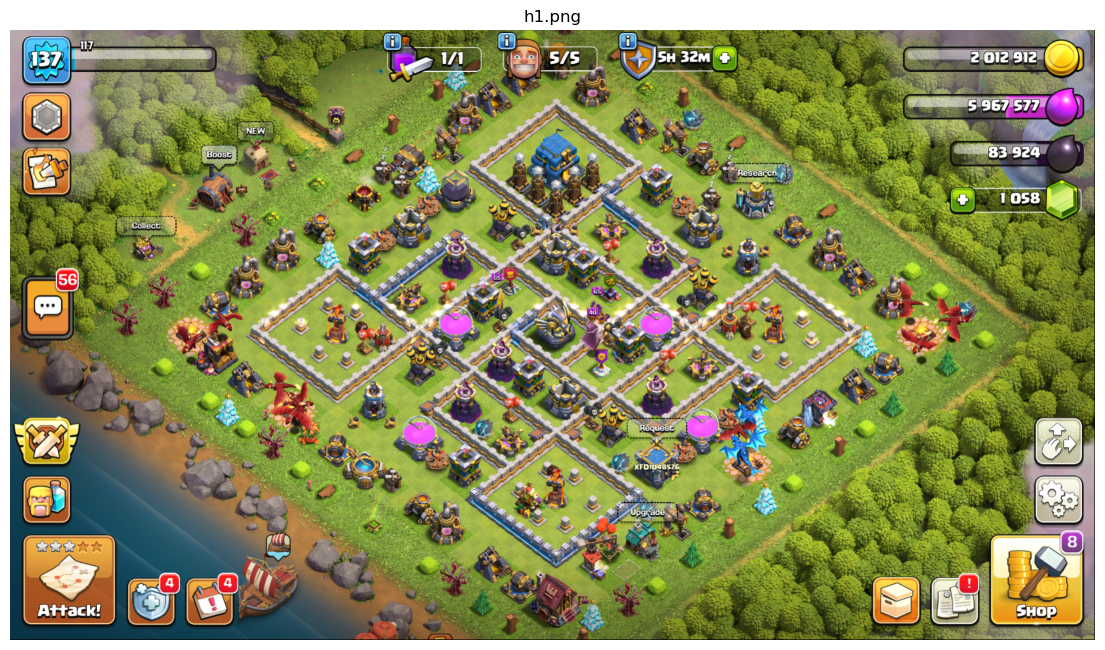

In [17]:
sample_img = image_files[0]

with Image.open(sample_img) as img:
    plt.figure(figsize=(14,8))
    plt.imshow(img)
    plt.axis("off")
    plt.title(sample_img.name)
    plt.show()

In [18]:
from collections import OrderedDict

summary = OrderedDict()

# Basic dataset stats
summary["total_images"] = len(coco["images"])
summary["total_annotations"] = len(coco["annotations"])
summary["total_classes"] = len(coco["categories"])

# Class distribution
summary["class_distribution"] = ann_df["class_name"].value_counts().to_dict()

# Objects per image
obj_stats = ann_df.groupby("image_id").size().describe()
summary["objects_per_image"] = {
    "min": int(obj_stats["min"]),
    "max": int(obj_stats["max"]),
    "mean": round(obj_stats["mean"], 2),
    "median": round(ann_df.groupby("image_id").size().median(), 2),
    "std": round(obj_stats["std"], 2)
}

# Area stats
area_stats = ann_df["area"].describe()
summary["object_area"] = {
    "min": round(area_stats["min"], 2),
    "max": round(area_stats["max"], 2),
    "mean": round(area_stats["mean"], 2),
    "median": round(ann_df["area"].median(), 2),
    "std": round(area_stats["std"], 2)
}

# Polygon complexity
poly_stats = ann_df["polygon_points"].describe()
summary["polygon_points"] = {
    "min": int(poly_stats["min"]),
    "max": int(poly_stats["max"]),
    "mean": round(poly_stats["mean"], 2),
    "median": round(ann_df["polygon_points"].median(), 2),
    "std": round(poly_stats["std"], 2)
}

# Optional imbalance ratio
counts = ann_df["class_name"].value_counts()
summary["class_imbalance_ratio"] = round(counts.max() / counts.min(), 2)

# Pretty print
import pprint
pp = pprint.PrettyPrinter(indent=2, width=120)
pp.pprint(summary)

OrderedDict([ ('total_images', 100),
              ('total_annotations', 2976),
              ('total_classes', 15),
              ( 'class_distribution',
                { 'air_defense': 188,
                  'air_sweeper': 124,
                  'archer_tower': 453,
                  'bomb_tower': 121,
                  'canon': 362,
                  'clan_castle': 62,
                  'dark_elixer_storage': 64,
                  'eagle_artillery': 65,
                  'elixer_storage': 255,
                  'gold_storage': 270,
                  'inferno_tower': 176,
                  'mortar': 214,
                  'town_hall': 64,
                  'wizard_tower': 295,
                  'x_bow': 263}),
              ('objects_per_image', {'max': 51, 'mean': 30.37, 'median': 29.5, 'min': 5, 'std': 13.99}),
              ('object_area', {'max': 126931.0, 'mean': 9808.61, 'median': 7015.5, 'min': 550.0, 'std': 8977.35}),
              ('polygon_points', {'max': 37, 'mean': 11.4

In [19]:
counts = ann_df["class_name"].value_counts()

print("Top 5 most frequent classes:")
print(counts.head(5).to_dict())

print("\nBottom 5 least frequent classes:")
print(counts.tail(5).to_dict())

Top 5 most frequent classes:
{'archer_tower': 453, 'canon': 362, 'wizard_tower': 295, 'gold_storage': 270, 'x_bow': 263}

Bottom 5 least frequent classes:
{'bomb_tower': 121, 'eagle_artillery': 65, 'town_hall': 64, 'dark_elixer_storage': 64, 'clan_castle': 62}


In [20]:
YOLO_DIR = BASE_DIR / "yolo_dataset_1"

for split in ["train", "val"]:
    (YOLO_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

print("YOLO dataset folders created.")

YOLO dataset folders created.


In [22]:
from sklearn.model_selection import train_test_split
import shutil

IMG_W, IMG_H = 1920, 1080

# image id -> filename
img_map = {img["id"]: img["file_name"] for img in coco["images"]}

# category remap to 0-based
cat_ids = sorted(cat_map.keys())
cat_remap = {cid: i for i, cid in enumerate(cat_ids)}

# group annotations by image
ann_by_img = defaultdict(list)
for ann in coco["annotations"]:
    ann_by_img[ann["image_id"]].append(ann)

# split
all_image_ids = list(img_map.keys())
train_ids, val_ids = train_test_split(all_image_ids, test_size=0.2, random_state=42)

def convert_split(image_ids, split):
    for img_id in image_ids:
        fname = img_map[img_id]
        src_img = UPLOADS_DIR / fname
        dst_img = YOLO_DIR / "images" / split / fname

        shutil.copy(src_img, dst_img)

        label_path = YOLO_DIR / "labels" / split / f"{Path(fname).stem}.txt"

        with open(label_path, "w") as f:
            for ann in ann_by_img[img_id]:
                cls = cat_remap[ann["category_id"]]
                seg = ann["segmentation"][0]

                coords = []
                for i in range(0, len(seg), 2):
                    x = seg[i] / IMG_W
                    y = seg[i+1] / IMG_H
                    coords.extend([x, y])

                line = f"{cls} " + " ".join(f"{c:.6f}" for c in coords)
                f.write(line + "\n")

convert_split(train_ids, "train")
convert_split(val_ids, "val")

print("Conversion complete.")
print(f"Train images: {len(train_ids)}")
print(f"Val images: {len(val_ids)}")

Conversion complete.
Train images: 80
Val images: 20


In [23]:
yaml_content = f"""
path: {YOLO_DIR}
train: images/train
val: images/val

names:
"""

for cid in cat_ids:
    yaml_content += f"  {cat_remap[cid]}: {cat_map[cid]}\n"

with open(YOLO_DIR / "data.yaml", "w") as f:
    f.write(yaml_content)

print(yaml_content)


path: /mnt/f/CocDatasets/Perception1/yolo_dataset_1
train: images/train
val: images/val

names:
  0: canon
  1: archer_tower
  2: mortar
  3: air_defense
  4: wizard_tower
  5: air_sweeper
  6: bomb_tower
  7: x_bow
  8: inferno_tower
  9: eagle_artillery
  10: town_hall
  11: gold_storage
  12: elixer_storage
  13: dark_elixer_storage
  14: clan_castle

